In [63]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

## 1. Data Cleaning & Auditing

We first load and inspect the raw Formula 1 tables before applying any cleaning.
Cleaning decisions will be based on issues identified through programmatic checks
and visualizations.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020"

circuits_raw = pd.read_csv(f"{BASE_PATH}/circuits.csv")
constructors_raw = pd.read_csv(f"{BASE_PATH}/constructors.csv")
constructor_results_raw = pd.read_csv(f"{BASE_PATH}/constructor_results.csv")
constructor_standings_raw = pd.read_csv(f"{BASE_PATH}/constructor_standings.csv")
drivers_raw = pd.read_csv(f"{BASE_PATH}/drivers.csv")
driver_standings_raw = pd.read_csv(f"{BASE_PATH}/driver_standings.csv")
races_raw = pd.read_csv(f"{BASE_PATH}/races.csv")
results_raw = pd.read_csv(f"{BASE_PATH}/results.csv")
qualifying_raw = pd.read_csv(f"{BASE_PATH}/qualifying.csv")
lap_times_raw = pd.read_csv(f"{BASE_PATH}/lap_times.csv")
pit_stops_raw = pd.read_csv(f"{BASE_PATH}/pit_stops.csv")
sprint_results_raw = pd.read_csv(f"{BASE_PATH}/sprint_results.csv")
seasons_raw = pd.read_csv(f"{BASE_PATH}/seasons.csv")
status_raw = pd.read_csv(f"{BASE_PATH}/status.csv")

tables_raw = {
    "circuits": circuits_raw,
    "constructors": constructors_raw,
    "constructor_results": constructor_results_raw,
    "constructor_standings": constructor_standings_raw,
    "drivers": drivers_raw,
    "driver_standings": driver_standings_raw,
    "races": races_raw,
    "results": results_raw,
    "qualifying": qualifying_raw,
    "lap_times": lap_times_raw,
    "pit_stops": pit_stops_raw,
    "sprint_results": sprint_results_raw,
    "seasons": seasons_raw,
    "status": status_raw
}

print("Number of tables loaded:", len(tables_raw))

Number of tables loaded: 14


## 2. Initial EDA — Dataset Overview

We first inspect the size and structure of each table programmatically.
This helps us understand the scale and grain of the relational dataset before cleaning.

In [65]:
overview = []

for name, df in tables_raw.items():
    overview.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview).sort_values("rows", ascending=False)

overview_df

,table,rows,columns,duplicate_rows
9,lap_times,589081,6,0
5,driver_standings,34863,7,0
7,results,26759,18,0
3,constructor_standings,13391,7,0
2,constructor_results,12625,5,0
10,pit_stops,11371,7,0
8,qualifying,10494,9,0
6,races,1125,18,0
4,drivers,861,9,0
11,sprint_results,360,16,0


### Observation

No table contains exact duplicate rows.

However, this does not guarantee that the required modeling grain is valid. The `results` table must still be checked separately for repeated `(raceId, driverId)` combinations, since historical shared-drive cases can create multiple rows for the same driver in one race.

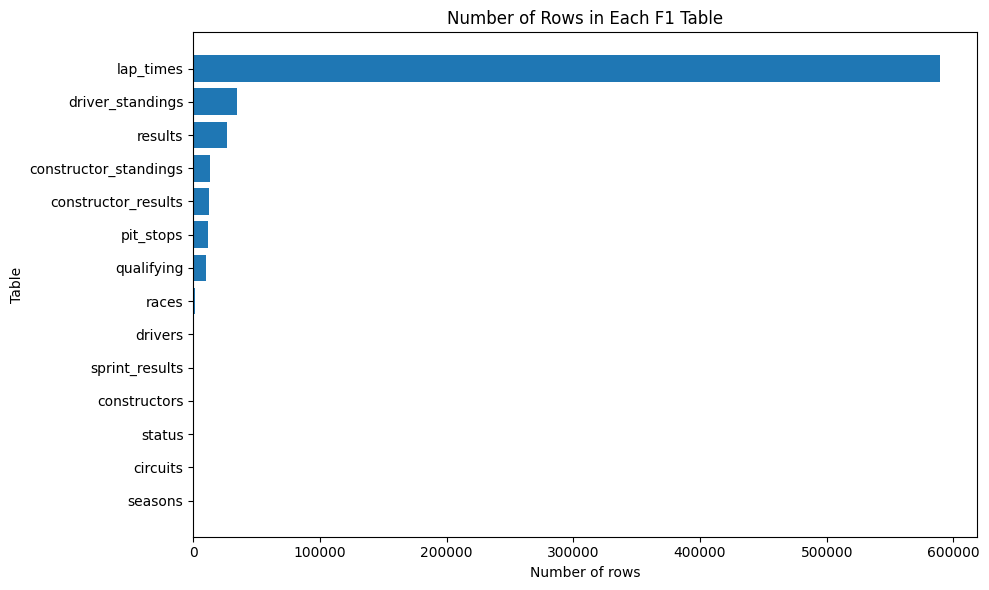

In [66]:
plt.figure(figsize=(10, 6))

plot_df = overview_df.sort_values("rows")

plt.barh(plot_df["table"], plot_df["rows"])

plt.xlabel("Number of rows")
plt.ylabel("Table")
plt.title("Number of Rows in Each F1 Table")

plt.tight_layout()
plt.show()

### Observation
The dataset contains tables with very different sizes and grains. For example, event-level tables such as lap times contain many more rows than lookup tables such as circuits or constructors.

Therefore, cleaning and duplicate checks should be performed according to the meaning and key structure of each table rather than applying the same rule to all tables.

## 3. Missing Values and Sentinel Analysis

The dataset uses the literal value `\N` as a placeholder for missing data.
We first identify where these sentinel values occur before cleaning so that the cleaning decision is based on observed missingness.

In [67]:
missing_summary = []

for name, df in tables_raw.items():
    for col in df.columns:
        sentinel_count = (df[col].astype(str) == r"\N").sum()

        if sentinel_count > 0:
            missing_summary.append({
                "table": name,
                "column": col,
                "sentinel_count": sentinel_count,
                "sentinel_pct": sentinel_count / len(df) * 100
            })

missing_summary_df = pd.DataFrame(missing_summary)

missing_summary_df.sort_values(
    "sentinel_pct",
    ascending=False
).head(30)

,table,column,sentinel_count,sentinel_pct
0,constructor_results,status,12608,99.865347
13,races,sprint_time,1110,98.666667
12,races,sprint_date,1107,98.400000
9,races,fp3_time,1072,95.288889
7,races,fp2_time,1057,93.955556
5,races,fp1_time,1057,93.955556
11,races,quali_time,1057,93.955556
8,races,fp3_date,1053,93.600000
1,drivers,number,802,93.147503
4,races,fp1_date,1035,92.000000


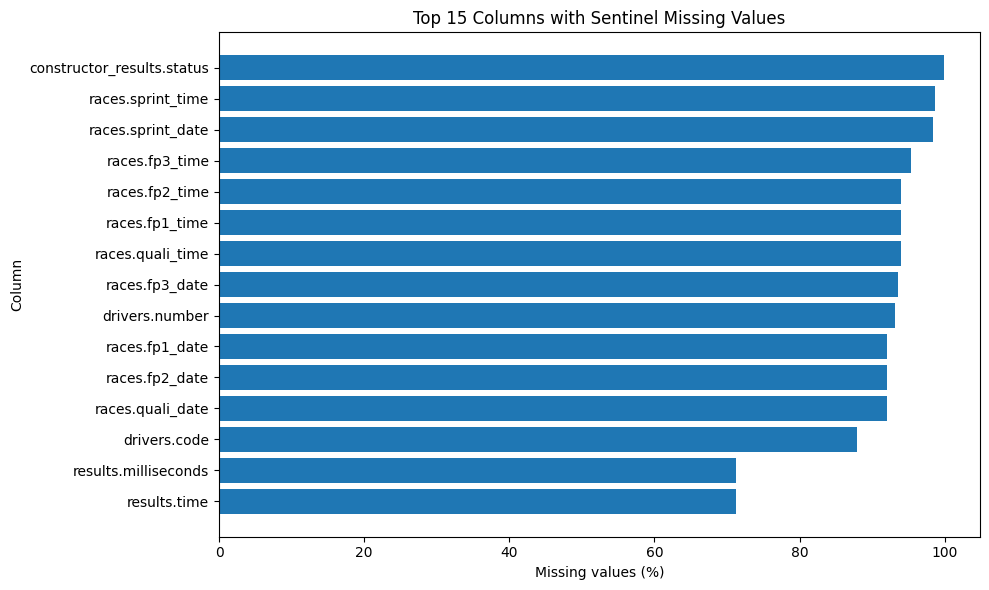

In [68]:
top_missing = (
    missing_summary_df
    .sort_values("sentinel_pct", ascending=False)
    .head(15)
    .copy()
)

top_missing["label"] = top_missing["table"] + "." + top_missing["column"]

plt.figure(figsize=(10, 6))

plt.barh(
    top_missing["label"][::-1],
    top_missing["sentinel_pct"][::-1]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Top 15 Columns with Sentinel Missing Values")

plt.tight_layout()
plt.show()

### Observation and Cleaning Decision

The amount of missing data differs across columns.

Some columns, such as `constructor_results.status` and several practice/sprint fields in `races`, have very high missingness, while others have moderate or low missingness.

Because the missing values have different meanings depending on the column, we will not apply one imputation method to every field.

At this cleaning stage, the literal `\N` sentinel values will be converted to proper missing values (`NaN`). Any later imputation or feature removal will be decided separately based on the meaning and usefulness of each feature.

In [69]:
tables_clean = {
    name: df.copy()
    for name, df in tables_raw.items()
}

for name, df in tables_clean.items():
    df.replace(r"\N", np.nan, inplace=True)

In [70]:
remaining_sentinels = 0

for name, df in tables_clean.items():
    remaining_sentinels += (df.astype(str) == r"\N").sum().sum()

print("Remaining literal \\N values:", remaining_sentinels)

Remaining literal \N values: 0


## 4. Semantic Typing

Some columns are stored as strings even though they represent dates or durations.
We convert them into appropriate data types so they can be processed correctly later.

In [71]:
date_columns = {
    "drivers": ["dob"],
    "races": ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
}

for table_name, columns in date_columns.items():
    for col in columns:
        if col in tables_clean[table_name].columns:
            tables_clean[table_name][col] = pd.to_datetime(
                tables_clean[table_name][col],
                errors="coerce"
            )

In [72]:
print(tables_clean["drivers"]["dob"].dtype)
print(tables_clean["races"]["date"].dtype)

datetime64[ns]
datetime64[ns]


### Justification

Date columns are converted to `datetime` so they can be sorted, compared, and used in time-based analysis correctly.

`errors="coerce"` is used so invalid or unavailable dates become missing values instead of causing errors.

### Duration Conversion

Some timing columns are stored as strings such as `1:23.456`.
We convert them to numeric seconds so they can be analyzed and compared mathematically.

In [73]:
def time_to_seconds(value):
    if pd.isna(value):
        return np.nan

    parts = str(value).split(":")

    try:
        if len(parts) == 2:
            minutes, seconds = parts
            return float(minutes) * 60 + float(seconds)

        elif len(parts) == 3:
            hours, minutes, seconds = parts
            return (
                float(hours) * 3600
                + float(minutes) * 60
                + float(seconds)
            )

        else:
            return float(value)

    except ValueError:
        return np.nan

In [74]:
tables_clean["qualifying"]["q1_seconds"] = (
    tables_clean["qualifying"]["q1"].apply(time_to_seconds)
)

tables_clean["qualifying"]["q2_seconds"] = (
    tables_clean["qualifying"]["q2"].apply(time_to_seconds)
)

tables_clean["qualifying"]["q3_seconds"] = (
    tables_clean["qualifying"]["q3"].apply(time_to_seconds)
)

tables_clean["lap_times"]["time_seconds"] = (
    tables_clean["lap_times"]["time"].apply(time_to_seconds)
)

tables_clean["pit_stops"]["duration_seconds"] = (
    tables_clean["pit_stops"]["duration"].apply(time_to_seconds)
)

In [75]:
tables_clean["qualifying"][
    ["q1", "q1_seconds", "q2", "q2_seconds", "q3", "q3_seconds"]
].head(10)

,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:26.572,86.572,1:25.187,85.187,1:26.714,86.714
1,1:26.103,86.103,1:25.315,85.315,1:26.869,86.869
2,1:25.664,85.664,1:25.452,85.452,1:27.079,87.079
3,1:25.994,85.994,1:25.691,85.691,1:27.178,87.178
4,1:25.960,85.960,1:25.518,85.518,1:27.236,87.236
5,1:26.427,86.427,1:26.101,86.101,1:28.527,88.527
6,1:26.295,86.295,1:26.059,86.059,1:28.687,88.687
7,1:26.381,86.381,1:26.063,86.063,1:29.041,89.041
8,1:26.919,86.919,1:26.164,86.164,1:29.593,89.593
9,1:26.702,86.702,1:25.842,85.842,NaN,NaN


### Observation

The qualifying time strings were successfully converted to numeric seconds while missing values remained as `NaN`.

This makes the timing data easier to compare and use in later numerical analysis without inventing values for missing sessions.

## 5. Driver-Race Duplicate Check

The final modeling table must contain one row for each driver in each race. Therefore, we check whether the combination `(raceId, driverId)` is unique in the `results` table.

In [76]:
driver_race_counts = (
    tables_clean["results"]
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="count")
)

duplicate_driver_races = driver_race_counts[
    driver_race_counts["count"] > 1
]

print(
    "Number of duplicated driver-race combinations:",
    len(duplicate_driver_races)
)

duplicate_driver_races.head()

Number of duplicated driver-race combinations: 85


,raceId,driverId,count
13659,540,229,2
17821,717,373,2
18222,733,465,2
18445,742,475,2
18532,745,418,2


In [77]:
duplicate_details = (
    tables_clean["results"]
    .merge(
        duplicate_driver_races[["raceId", "driverId"]],
        on=["raceId", "driverId"],
        how="inner"
    )
    .merge(
        tables_clean["races"][["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
)

duplicate_by_year = (
    duplicate_details[
        ["year", "raceId", "driverId"]
    ]
    .drop_duplicates()
    .groupby("year")
    .size()
)

duplicate_by_year

year
1950     4
1951     4
1952     3
1953    14
1954    16
1955    15
1956    12
1957     8
1958     3
1960     1
1961     2
1962     1
1964     1
1978     1
dtype: int64

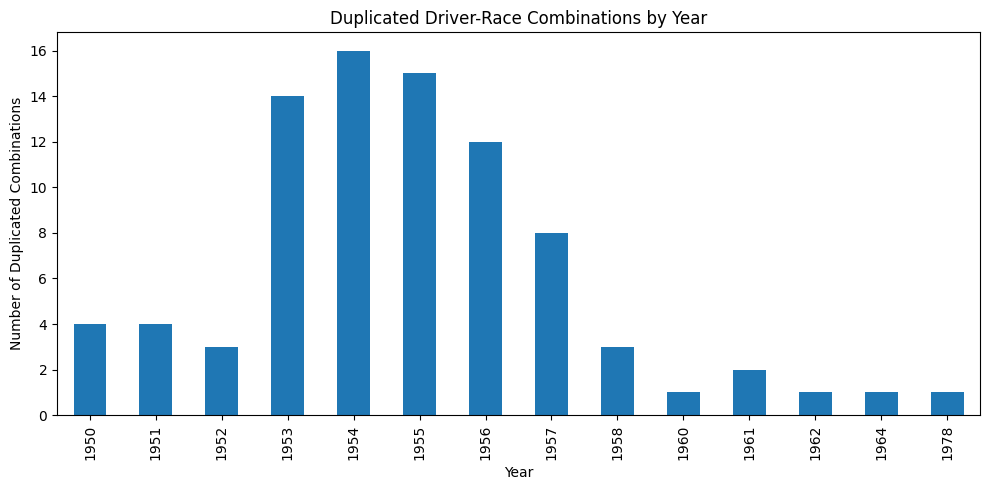

In [78]:
plt.figure(figsize=(10, 5))

duplicate_by_year.plot(kind="bar")

plt.title("Duplicated Driver-Race Combinations by Year")
plt.xlabel("Year")
plt.ylabel("Number of Duplicated Combinations")

plt.tight_layout()
plt.show()

### Observation

The duplicated driver-race combinations are concentrated mainly in the earlier Formula 1 seasons.

This matches the historical shared-drive issue, where a driver could appear more than once in the same race after switching cars.

Since the final modeling table requires one row per `(raceId, driverId)`, a consistent rule is needed to keep only one record for each duplicated pair.

### Duplicate Resolution Rule

Most duplicated `(raceId, driverId)` combinations occur in early Formula 1 seasons and are related to historical shared-drive cases.

To keep one row per driver and race without using post-race information, duplicates are resolved using the starting grid:

- Rows with a valid non-zero grid position are preferred.
- If multiple valid rows remain, the row with the lowest grid position is kept.
- `resultId` is used only as a tie-breaker.

`positionOrder` is not used for duplicate resolution because it is a post-race outcome and could introduce data leakage.

In [79]:
results_clean = tables_clean["results"].copy()

results_clean["valid_grid"] = results_clean["grid"] > 0

results_clean = (
    results_clean
    .sort_values(
        by=["raceId", "driverId", "valid_grid", "grid", "resultId"],
        ascending=[True, True, False, True, True]
    )
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .drop(columns="valid_grid")
)

tables_clean["results"] = results_clean

In [80]:
remaining_duplicates = (
    tables_clean["results"]
    .duplicated(subset=["raceId", "driverId"])
    .sum()
)

print("Remaining duplicated driver-race combinations:", remaining_duplicates)
print("Rows before:", len(results_raw))
print("Rows after:", len(tables_clean["results"]))

Remaining duplicated driver-race combinations: 0
Rows before: 26759
Rows after: 26668


### Result

After applying the duplicate-resolution rule, no duplicated `(raceId, driverId)` combinations remain.

The `results` table decreased from 26,759 to 26,668 rows, giving one record per driver per race as required.

## 6. Primary Key Auditing

We verify that the expected primary key of each table is unique and contains no missing values.
For tables without a single identifier column, the appropriate composite key is checked.

In [81]:
primary_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "qualifying": ["qualifyId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "sprint_results": ["resultId"],
    "seasons": ["year"],
    "status": ["statusId"]
}

pk_audit = []

for table_name, key_cols in primary_keys.items():
    df = tables_clean[table_name]

    missing_keys = df[key_cols].isna().any(axis=1).sum()
    duplicate_keys = df.duplicated(subset=key_cols).sum()

    pk_audit.append({
        "table": table_name,
        "key": ", ".join(key_cols),
        "missing_key_rows": missing_keys,
        "duplicate_key_rows": duplicate_keys
    })

pk_audit_df = pd.DataFrame(pk_audit)

pk_audit_df

,table,key,missing_key_rows,duplicate_key_rows
0,circuits,circuitId,0,0
1,constructors,constructorId,0,0
2,constructor_results,constructorResultsId,0,0
3,constructor_standings,constructorStandingsId,0,0
4,drivers,driverId,0,0
5,driver_standings,driverStandingsId,0,0
6,races,raceId,0,0
7,results,resultId,0,0
8,qualifying,qualifyId,0,0
9,lap_times,"raceId, driverId, lap",0,0


### Observation

All expected primary keys are complete and unique.

No table contains missing key values or duplicated primary/composite keys, so the key structure is internally consistent after cleaning.

## 7. Foreign Key Auditing

We check whether foreign-key values in child tables can be matched to the corresponding parent tables.

This verifies that the relational tables can be joined consistently without unmatched identifiers.

In [82]:
foreign_keys = [
    ("races", "circuitId", "circuits", "circuitId"),

    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),

    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),

    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),

    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),

    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),

    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),

    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),

    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId")
]

fk_audit = []

for child_table, child_col, parent_table, parent_col in foreign_keys:
    child_values = tables_clean[child_table][child_col]
    parent_values = tables_clean[parent_table][parent_col]

    unmatched = (
        child_values.notna()
        & ~child_values.isin(parent_values)
    ).sum()

    fk_audit.append({
        "child_table": child_table,
        "foreign_key": child_col,
        "parent_table": parent_table,
        "parent_key": parent_col,
        "unmatched_rows": unmatched
    })

fk_audit_df = pd.DataFrame(fk_audit)

fk_audit_df

,child_table,foreign_key,parent_table,parent_key,unmatched_rows
0,races,circuitId,circuits,circuitId,0
1,results,raceId,races,raceId,0
2,results,driverId,drivers,driverId,0
3,results,constructorId,constructors,constructorId,0
4,results,statusId,status,statusId,0
5,qualifying,raceId,races,raceId,0
6,qualifying,driverId,drivers,driverId,0
7,qualifying,constructorId,constructors,constructorId,0
8,lap_times,raceId,races,raceId,0
9,lap_times,driverId,drivers,driverId,0


### Observation

All checked foreign keys successfully match their corresponding parent-table keys.

No unmatched foreign-key values were found, which indicates that the relational links between the cleaned tables are consistent.

## 8. Post-Cleaning Verification

After cleaning, we verify that the main data-quality issues identified earlier have been resolved.

In [83]:
before_after = pd.DataFrame({
    "check": [
        "Literal sentinel values",
        "Duplicated (raceId, driverId)"
    ],
    "before": [
        sum(
            (df.astype(str) == r"\N").sum().sum()
            for df in tables_raw.values()
        ),
        85
    ],
    "after": [
        sum(
            (df.astype(str) == r"\N").sum().sum()
            for df in tables_clean.values()
        ),
        tables_clean["results"]
        .duplicated(subset=["raceId", "driverId"])
        .sum()
    ]
})

before_after

,check,before,after
0,Literal sentinel values,160076,0
1,"Duplicated (raceId, driverId)",85,0


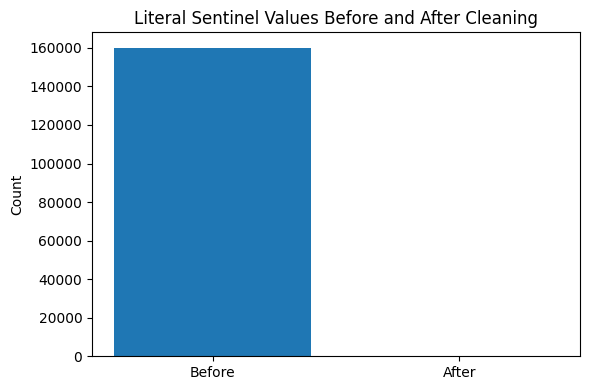

In [84]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Before", "After"],
    [before_after.loc[0, "before"], before_after.loc[0, "after"]]
)

plt.ylabel("Count")
plt.title("Literal Sentinel Values Before and After Cleaning")

plt.tight_layout()
plt.show()

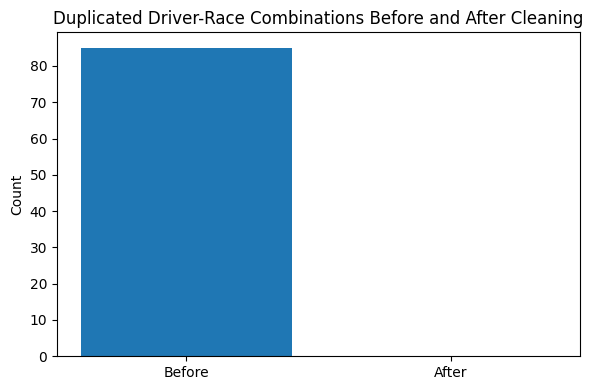

In [85]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Before", "After"],
    [before_after.loc[1, "before"], before_after.loc[1, "after"]]
)

plt.ylabel("Count")
plt.title("Duplicated Driver-Race Combinations Before and After Cleaning")

plt.tight_layout()
plt.show()

### Final Cleaning Result

The literal `\N` sentinel values were successfully converted to proper missing values.

The duplicated `(raceId, driverId)` combinations were also resolved, leaving one row per driver per race.

Primary-key and foreign-key audits showed no remaining integrity problems in the checked tables.

### Cleaned Dataset Summary

The following tables are now ready for the next stages of analysis and feature engineering.

In [86]:
clean_summary = []

for name, df in tables_clean.items():
    clean_summary.append({
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

clean_summary_df = pd.DataFrame(clean_summary).sort_values(
    "rows",
    ascending=False
)

clean_summary_df

,table,rows,columns
9,lap_times,589081,7
5,driver_standings,34863,7
7,results,26668,18
3,constructor_standings,13391,7
2,constructor_results,12625,5
10,pit_stops,11371,8
8,qualifying,10494,12
6,races,1125,18
4,drivers,861,9
11,sprint_results,360,16


## 9. Data-Engineering Question 3 — Mechanical Retirement Rate by Constructor

**Question:** Which constructors have the highest mechanical-retirement rate in 2014–2021 (turbo-hybrid era) vs. 2022–2024 (ground-effect era)?

**Tables joined (multi-hop):** `results` → `status` (why the race ended) → `races` (year) → `constructors` (team name).

**Grain:** one row per driver race *start* (from the cleaned `results`, already unique per `(raceId, driverId)`).

**Definition used:** a *mechanical retirement* is a start that ended early because a car component failed.
Crashes, driver errors, disqualifications and regulation decisions are **not** mechanical.

**Rate:** `mechanical retirements / race starts` per constructor per era.

**Pre-race cutoff:** not relevant here — this is a descriptive, post-race analysis. `status` is post-race information and is **never** used as a model feature.

In [87]:
res = tables_clean["results"].copy()
res["statusId"] = pd.to_numeric(res["statusId"], errors="coerce")
res["laps"] = pd.to_numeric(res["laps"], errors="coerce")

q3 = (
    res[["raceId", "driverId", "constructorId", "statusId", "laps", "grid"]]
    .merge(tables_clean["status"][["statusId", "status"]], on="statusId", how="left")
    .merge(tables_clean["races"][["raceId", "year"]], on="raceId", how="left")
    .merge(tables_clean["constructors"][["constructorId", "name"]], on="constructorId", how="left")
    .rename(columns={"name": "constructor"})
)

q3 = q3[q3["year"].between(2014, 2024)].copy()
q3["era"] = np.where(q3["year"] <= 2021, "2014–2021", "2022–2024")

print("Rows 2014–2024:", len(q3))
print("Missing status after join:", q3["status"].isna().sum())
print("Missing constructor after join:", q3["constructor"].isna().sum())

Rows 2014–2024: 4626
Missing status after join: 0
Missing constructor after join: 0


In [88]:
status_counts = q3["status"].value_counts()
print("Distinct status values in 2014–2024:", len(status_counts))
status_counts

Distinct status values in 2014–2024: 66


status
Finished          2403
+1 Lap            1178
+2 Laps            208
Collision          150
Accident            85
                  ... 
Water pump           1
Cooling system       1
Fuel pump            1
Differential         1
+7 Laps              1
Name: count, Length: 66, dtype: int64

### Status mapping

Each status is assigned to one of five groups. The mapping is explicit (not keyword-guessed) so it can be audited.

| Group | Meaning | Counted as mechanical? |
|---|---|---|
| `finished` | Reached the flag (`Finished`, `+1 Lap`, …) | No |
| `mechanical` | A car component failed (engine, gearbox, power unit, hydraulics, brakes, …) | **Yes** |
| `accident_driver` | Crash, collision, spin, damage, driver illness | No |
| `other` | Disqualification, withdrawal, regulation/team decisions, ambiguous causes (`Retired`, tyre/puncture) | No |
| `not_started` | Did not start the race | Removed from the denominator |

**Judgement calls (document these in the report):**
- `Retired` is a generic label with no cause, so it is **not** counted as mechanical (conservative choice).
- Tyre failures and punctures are usually caused by debris or contact, so they go to `other`.
- Wing failures (`Front wing`, `Rear wing`) are counted as mechanical, since in 2014–2024 these labels are used for component failures; contact damage is labelled `Collision damage` / `Damage` instead.
- `Out of fuel` and `Underweight` are team/regulation issues, not component failures → `other`.

In [89]:
MECHANICAL = {
    "Engine", "Gearbox", "Transmission", "Clutch", "Hydraulics", "Electrical",
    "Radiator", "Suspension", "Brakes", "Differential", "Overheating", "Mechanical",
    "Driveshaft", "Fuel pressure", "Water pressure", "Wheel", "Throttle", "Steering",
    "Technical", "Electronics", "Exhaust", "Oil leak", "Wheel rim", "Water leak",
    "Fuel pump", "Track rod", "Oil pressure", "Engine fire", "Engine misfire",
    "Wheel nut", "Pneumatics", "Handling", "Fire", "Wheel bearing", "Fuel system",
    "Oil line", "Fuel leak", "Power loss", "Vibrations", "Drivetrain", "Ignition",
    "Chassis", "Battery", "Halfshaft", "Crankshaft", "Alternator", "Oil pump",
    "Injection", "Distributor", "Turbo", "CV joint", "Water pump", "Spark plugs",
    "Fuel pipe", "Oil pipe", "Axle", "Water pipe", "Magneto", "Supercharger",
    "Power Unit", "ERS", "Brake duct", "Seat", "Undertray", "Cooling system",
    "Heat shield fire", "Front wing", "Rear wing", "Broken wing", "Launch control",
    "Fuel", "Refuelling", "Stalled", "Driver Seat", "Safety belt",
}

ACCIDENT_DRIVER = {
    "Accident", "Collision", "Collision damage", "Spun off", "Damage", "Debris",
    "Fatal accident", "Injured", "Injury", "Eye injury", "Physical", "Illness",
    "Driver unwell",
}

NOT_STARTED = {
    "Did not qualify", "Did not prequalify", "107% Rule", "Did not start",
    "Not restarted",
}

OTHER = {
    "Disqualified", "Excluded", "Withdrew", "Retired", "Not classified",
    "Tyre", "Puncture", "Tyre puncture", "Out of fuel", "Underweight",
    "Safety", "Safety concerns", "Fuel rig",
}


def status_group(s):
    if pd.isna(s):
        return "unmapped"
    if s == "Finished" or str(s).startswith("+"):
        return "finished"
    if s in MECHANICAL:
        return "mechanical"
    if s in ACCIDENT_DRIVER:
        return "accident_driver"
    if s in NOT_STARTED:
        return "not_started"
    if s in OTHER:
        return "other"
    return "unmapped"


q3["status_group"] = q3["status"].apply(status_group)

unmapped = q3.loc[q3["status_group"] == "unmapped", "status"].value_counts()
print("Unmapped statuses:", len(unmapped))
print(unmapped)

q3["status_group"].value_counts()

Unmapped statuses: 0
Series([], Name: count, dtype: int64)


status_group
finished           3825
mechanical          402
accident_driver     311
other                88
Name: count, dtype: int64

In [90]:
starts = q3[q3["status_group"] != "not_started"].copy()
starts["mechanical"] = (starts["status_group"] == "mechanical").astype(int)

MIN_STARTS = 30

mech_rates = (
    starts.groupby(["era", "constructor"])
    .agg(starts=("mechanical", "size"), mech_dnfs=("mechanical", "sum"))
    .reset_index()
)
mech_rates["mech_rate_pct"] = mech_rates["mech_dnfs"] / mech_rates["starts"] * 100
mech_rates = mech_rates[mech_rates["starts"] >= MIN_STARTS]

era_overall = starts.groupby("era")["mechanical"].mean() * 100
print("Overall mechanical-retirement rate per era (%):")
print(era_overall.round(2))

for era in ["2014–2021", "2022–2024"]:
    print(f"\nTop 5 constructors, {era}:")
    print(
        mech_rates[mech_rates["era"] == era]
        .sort_values("mech_rate_pct", ascending=False)
        .head(5)[["constructor", "starts", "mech_dnfs", "mech_rate_pct"]]
        .round(2)
        .to_string(index=False)
    )

Overall mechanical-retirement rate per era (%):
era
2014–2021    9.76
2022–2024    6.11
Name: mechanical, dtype: float64

Top 5 constructors, 2014–2021:
constructor  starts  mech_dnfs  mech_rate_pct
   Caterham      34          8          23.53
   Lotus F1      76         14          18.42
 Toro Rosso     242         39          16.12
    Renault     200         29          14.50
    McLaren     320         46          14.37

Top 5 constructors, 2022–2024:
   constructor  starts  mech_dnfs  mech_rate_pct
    Alfa Romeo      88         11          12.50
Alpine F1 Team     136         15          11.03
    AlphaTauri      88          7           7.95
       Ferrari     136          9           6.62
      Williams     135          8           5.93


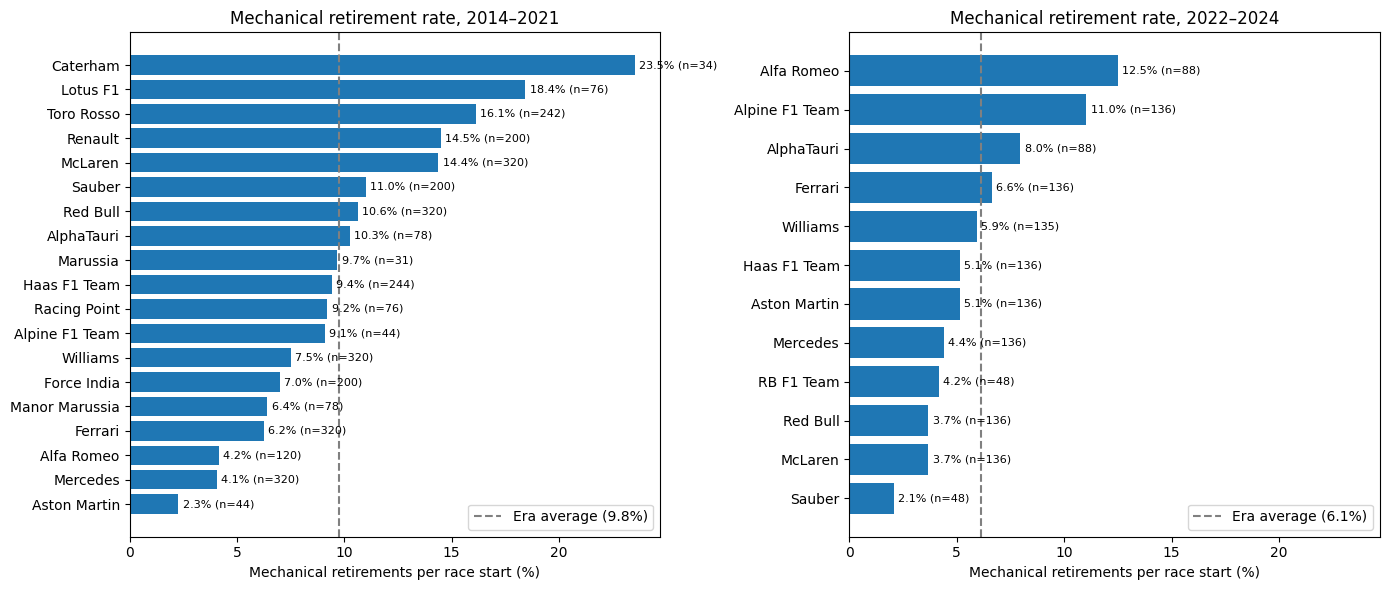

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, era in zip(axes, ["2014–2021", "2022–2024"]):
    d = mech_rates[mech_rates["era"] == era].sort_values("mech_rate_pct")
    ax.barh(d["constructor"], d["mech_rate_pct"])
    ax.axvline(era_overall[era], linestyle="--", color="gray",
               label=f"Era average ({era_overall[era]:.1f}%)")
    for y, (rate, n) in enumerate(zip(d["mech_rate_pct"], d["starts"])):
        ax.text(rate + 0.2, y, f"{rate:.1f}% (n={n})", va="center", fontsize=8)
    ax.set_title(f"Mechanical retirement rate, {era}")
    ax.set_xlabel("Mechanical retirements per race start (%)")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [92]:
top_causes = (
    starts[starts["mechanical"] == 1]
    .groupby(["era", "status"])
    .size()
    .reset_index(name="count")
    .sort_values(["era", "count"], ascending=[True, False])
    .groupby("era")
    .head(6)
)
top_causes

,era,status,count
9,2014–2021,Engine,59
2,2014–2021,Brakes,45
20,2014–2021,Power Unit,35
14,2014–2021,Gearbox,33
27,2014–2021,Suspension,24
7,2014–2021,Electrical,13
41,2022–2024,Engine,22
46,2022–2024,Gearbox,9
51,2022–2024,Power Unit,7
47,2022–2024,Hydraulics,5


### Answer and interpretation

- **2014–2021 (turbo-hybrid era):** the highest mechanical-retirement rates belong to **Caterham (23.5%)**, **Lotus F1 (18.4%)**, **Toro Rosso (16.1%)**, **Renault (14.5%)** and **McLaren (14.4%)**, against an era average of **9.8%**. Mercedes (4.1%) was among the most reliable.
- **2022–2024 (ground-effect era):** the highest rates belong to **Alfa Romeo (12.5%)**, **Alpine (11.0%)** and **AlphaTauri (8.0%)**, against an era average of **6.1%**. Red Bull and McLaren were among the most reliable (3.7%).
- **Change between eras:** the overall mechanical-retirement rate fell from **9.8% to 6.1%**, so cars became noticeably more reliable in the newer era. The ranking also reshuffled: McLaren went from one of the least reliable teams to one of the most reliable.
- **Failure causes:** engine failures were the most common cause in both eras, followed by brakes, power-unit and gearbox failures in 2014–2021, and gearbox and power-unit failures in 2022–2024.

**Grain:** one row per driver race start; non-starters (`Did not qualify`, `Did not start`, …) are removed from the denominator.

**Missingness:** all 66 distinct status values in 2014–2024 are mapped (unmapped check = 0), and every row joined to a status, race and constructor.

**Limitations:**
- Some rates rest on small samples (e.g. Caterham, n = 34; Aston Martin 2021, n = 44), so they are less stable than those of teams with 300+ starts.
- The status label is the official reason and can be vague; `Retired` was excluded, so rates are a lower bound.
- Rates use `constructorId`, so renamed teams (e.g. Toro Rosso → AlphaTauri → RB, Renault → Alpine, Racing Point → Aston Martin) appear as separate rows.
- Constructors with fewer than 30 starts in an era are not shown.